# GIVEPIFR 전용 개인정보 제공 태도 분석

이 노트북은 `privacy_class_regression_statsmodels.ipynb`에서 수행한 분석 중 `GIVEPIFR` 종속변수만 분리한 재현용 노트북이다.

- 원 종속변수: `GIVEPIFR`, 1=매우 동의, 5=매우 반대
- 분석 종속변수: `GIVEPIFR_R = 6 - GIVEPIFR`, 1=매우 반대, 5=매우 동의
- 로짓 종속변수: `GIVEPIFR_agree`, 원척도 1 또는 2를 1로 코딩
- 주 분석 객관적 계층 변수: `log_INCOM0`
- 소득 측정 강건성 분석: `INCOME_CAT`

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import display
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

## 1. 데이터 불러오기

In [2]:
DATA_PATH = Path(r"/home/pck/data_jour/sda_Team Project_/adt_2025_drop_0509.csv")
df_raw = pd.read_csv(DATA_PATH)

print(df_raw.shape)
display(df_raw.head())

(1211, 455)


,YEAR,RESPID,YRRESPID,FINALWT,SEX,AGE,MARITAL,EMPLY,WHYNOE,EDUC,GRADUATE,DROPYR,CURRYR,SPEDUC,SPGRAD,SPDROPYR,SPCURRYR,PAEDUC,PAGRAD,PADROPYR,MAEDUC,MAGRAD,MADROPYR,FBIRTHPL,MBIRTHPL,FAMILY16,WHYNOTPA23,EMPED,WGSTAT,WGPTFL,WGWKHR,WGSTAB,WGTENYR,WGTENMO,WGSECT,WGUNN,WGUNNP,WGNOEMP,SFSTAT,SFNOHI,SFPTFL,SFWKHR,SFTENYR,SFTENMO,NUMSUP,EMSUBO,UNWKEX,UNSTAT,UNNOHI,UNSUBO,...,WHYNOE2,RELATE3,GENDER3,OLD3,MAR3,AWAY3,WHYAWY3,EMPLY3,WHYNOE3,RELATE4,GENDER4,OLD4,MAR4,AWAY4,WHYAWY4,EMPLY4,WHYNOE4,RELATE5,GENDER5,OLD5,MAR5,AWAY5,WHYAWY5,EMPLY5,WHYNOE5,RELATE6,GENDER6,OLD6,MAR6,AWAY6,EMPLY6,WHYNOE6,HHWHO,HDHEAD,HHSEX,HHAGE,HHMARI,HHAWAY,HHWHYAWY,HHEMPLY,HHWHYNOE,HHDNO,HOMPOP,SEPAPOP,UNRELAT,REGION,URBAN,SAMPLEAB,INTDATM,INTDATD
0,2025.0,101.0,202500101.0,1.349140,1.0,44.0,1.0,1.0,-1.0,4.0,1.0,-1.0,-1.0,5.0,1.0,-1.0,-1.0,4.0,1.0,-1.0,3.0,1.0,-1.0,410.0,410.0,1.0,-1.0,1.0,1.0,2.0,40.0,1.0,10.0,0.0,3.0,2.0,2.0,3.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,4.0,1.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,3.0,2.0,14.0,5.0,1.0,-1.0,2.0,2.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,44.0,1.0,1.0,-1.0,1.0,-1.0,11.0,3.0,0.0,0.0,1.0,1.0,1.0,4.0,6.0
1,2025.0,102.0,202500102.0,0.719461,2.0,62.0,1.0,2.0,3.0,3.0,1.0,-1.0,-1.0,3.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,1.0,1.0,-1.0,410.0,410.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,2.0,-1.0,2.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.0,2.0,1.0,65.0,1.0,1.0,-1.0,1.0,-1.0,2.0,2.0,0.0,0.0,1.0,1.0,2.0,4.0,6.0
2,2025.0,103.0,202500103.0,0.572766,2.0,50.0,1.0,2.0,18.0,3.0,1.0,-1.0,-1.0,3.0,1.0,-1.0,-1.0,3.0,1.0,-1.0,3.0,1.0,-1.0,410.0,410.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,2.0,-1.0,1.0,...,-1.0,3.0,2.0,17.0,-8.0,1.0,-1.0,2.0,2.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,2.0,2.0,1.0,51.0,1.0,1.0,-1.0,1.0,-1.0,4.0,3.0,0.0,0.0,1.0,1.0,2.0,4.0,7.0
3,2025.0,104.0,202500104.0,1.093403,1.0,62.0,1.0,1.0,-1.0,3.0,1.0,-1.0,-1.0,3.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,1.0,1.0,-1.0,410.0,410.0,1.0,-1.0,2.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,3.0,-1.0,-8.0,50.0,30.0,5.0,1.0,2.0,-1.0,-1.0,-1.0,-1.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,62.0,1.0,1.0,-1.0,1.0,-1.0,10.0,2.0,0.0,0.0,1.0,1.0,2.0,5.0,25.0
4,2025.0,105.0,202500105.0,1.093403,1.0,74.0,1.0,2.0,19.0,2.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,-1.0,1.0,1.0,-1.0,0.0,-1.0,-1.0,410.0,410.0,1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,2.0,-1.0,2.0,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.0,1.0,1.0,74.0,1.0,1.0,-1.0,2.0,19.0,12.0,2.0,0.0,0.0,1.0,1.0,2.0,4.0,8.0


## 2. 분석 변수 지정

`GIVEPIFR` 분석에 필요한 변수만 사용한다. `INCOME`은 범주형 소득 변수이므로 주 분석에는 넣지 않고, 마지막 강건성 분석에서 `INCOME_CAT`으로 사용한다.

In [3]:
raw_dv_var = "GIVEPIFR"
dv_var = "GIVEPIFR_R"
logit_dv_var = "GIVEPIFR_agree"

raw_core_vars = ["INCOME", "INCOM0", "RANK", "SATFIN", "FINPROS"]
core_vars = ["INCOME", "INCOM0", "RANK", "SATFIN_R", "FINPROS_R"]
raw_control_vars = ["AGE", "SEX", "EDUC", "ABLITINF", "TECHHARM"]
control_vars = ["AGE", "SEX", "EDUC", "ABLITINF_R", "TECHHARM_R"]
weight_var = "FINALWT"

analysis_vars_raw = [raw_dv_var] + raw_core_vars + raw_control_vars + [weight_var]

missing = [v for v in analysis_vars_raw if v not in df_raw.columns]
if missing:
    raise ValueError(f"데이터에 없는 변수: {missing}")

display(df_raw[analysis_vars_raw].describe().T)

,count,mean,std,min,25%,50%,75%,max
GIVEPIFR,1211.0,3.507019,1.121057,-8.000000,3.000000,4.00000,4.000000,5.000000
INCOME,1211.0,8.895128,6.527101,-8.000000,5.000000,9.00000,13.000000,21.000000
INCOM0,1211.0,448.386457,407.973516,-8.000000,216.000000,400.00000,600.000000,9000.000000
RANK,1211.0,5.065235,1.498717,1.000000,4.000000,5.00000,6.000000,10.000000
SATFIN,1211.0,3.182494,0.886384,1.000000,3.000000,3.00000,4.000000,5.000000
FINPROS,1211.0,2.777870,0.988047,-8.000000,2.000000,3.00000,3.000000,5.000000
AGE,1211.0,52.611891,15.651251,18.000000,40.000000,54.00000,64.000000,93.000000
SEX,1211.0,1.610239,0.487897,1.000000,1.000000,2.00000,2.000000,2.000000
EDUC,1211.0,3.469860,1.483142,-8.000000,3.000000,3.00000,5.000000,8.000000
ABLITINF,1211.0,2.347647,1.545626,-8.000000,2.000000,2.00000,3.000000,5.000000


## 3. 데이터 전처리

- `-8`은 공통 결측 코드로 처리한다.
- `ABLITINF`의 `-1`은 비해당으로 보고 결측 처리한다.
- `GIVEPIFR`, `SATFIN`, `FINPROS`, `ABLITINF`, `TECHHARM`은 분석 방향에 맞게 역코딩한다.
- `INCOM0`는 `log_INCOM0 = log(INCOM0 + 1)`로 변환한다.
- `INCOME`은 강건성 분석용 범주형 변수 `INCOME_CAT`으로 묶는다.

In [4]:
df = df_raw[analysis_vars_raw].copy()

# 공통 결측 코드 처리
for col in analysis_vars_raw:
    df[col] = df[col].replace(-8, np.nan)

# ABLITINF의 -1은 비해당으로 보고 결측 처리
df["ABLITINF"] = df["ABLITINF"].replace(-1, np.nan)

# 개인정보 제공 태도 역코딩: 원척도 1=매우 동의, 5=매우 반대
# 분석척도는 1=매우 반대, 5=매우 동의
df["GIVEPIFR_R"] = np.where(df["GIVEPIFR"].isin([1, 2, 3, 4, 5]), 6 - df["GIVEPIFR"], np.nan)

# 로짓모형용 이진 종속변수: 원척도 1=매우 동의, 2=동의를 1로 코딩
df["GIVEPIFR_agree"] = np.where(
    df["GIVEPIFR"].isin([1, 2]), 1,
    np.where(df["GIVEPIFR"].isin([3, 4, 5]), 0, np.nan)
)

# 핵심 독립변수/통제변수 역코딩
# SATFIN_R: 1=매우 불만족, 5=매우 만족
# FINPROS_R: 1=상당히 나빠질 것, 5=상당히 좋아질 것
# ABLITINF_R: 1=매우 낮음, 5=매우 높음
for v in ["SATFIN", "FINPROS", "ABLITINF"]:
    df[f"{v}_R"] = np.where(df[v].isin([1, 2, 3, 4, 5]), 6 - df[v], np.nan)

# TECHHARM_R: 값이 높을수록 기술위험 인식이 높음
df["TECHHARM_R"] = np.where(df["TECHHARM"].isin([1, 2, 3, 4, 5]), 6 - df["TECHHARM"], np.nan)

# 연속형 소득 로그 변환
df["log_INCOM0"] = np.log1p(df["INCOM0"].where(df["INCOM0"] >= 0, np.nan))

# INCOME 범주 묶기: 강건성 분석용
income_cat_bins = [-0.1, 2, 5, 8, 11, 14, 17, 21]
income_cat_labels = ["0-2", "3-5", "6-8", "9-11", "12-14", "15-17", "18-21"]
df["INCOME_CAT"] = pd.cut(
    df["INCOME"],
    bins=income_cat_bins,
    labels=income_cat_labels,
    include_lowest=True,
)

# 표준화 변수: 계수 크기 비교용
scale_vars = ["INCOM0", "log_INCOM0", "RANK", "SATFIN_R", "FINPROS_R", "AGE", "ABLITINF_R", "TECHHARM_R"]
for v in scale_vars:
    m = df[v].mean(skipna=True)
    s = df[v].std(skipna=True)
    df[f"z_{v}"] = (df[v] - m) / s

analysis_vars = ["GIVEPIFR_R", "INCOME", "INCOM0", "RANK", "SATFIN_R", "FINPROS_R", "AGE", "SEX", "EDUC", "ABLITINF_R", "TECHHARM_R", "FINALWT"]

print(df[analysis_vars + ["GIVEPIFR", "GIVEPIFR_agree", "log_INCOM0", "INCOME_CAT"]].isna().sum())
display(df[["GIVEPIFR", "GIVEPIFR_R", "GIVEPIFR_agree"]].head())
display(df[["SATFIN", "SATFIN_R", "FINPROS", "FINPROS_R", "ABLITINF", "ABLITINF_R", "TECHHARM", "TECHHARM_R"]].head())
display(df.head())

GIVEPIFR_R         1
INCOME            60
INCOM0            60
RANK               0
SATFIN_R           0
FINPROS_R          4
AGE                0
SEX                0
EDUC               1
ABLITINF_R        88
TECHHARM_R         1
FINALWT            0
GIVEPIFR           1
GIVEPIFR_agree     1
log_INCOM0        60
INCOME_CAT        60
dtype: int64


,GIVEPIFR,GIVEPIFR_R,GIVEPIFR_agree
0,3.0,3.0,0.0
1,2.0,4.0,1.0
2,3.0,3.0,0.0
3,2.0,4.0,1.0
4,4.0,2.0,0.0


,SATFIN,SATFIN_R,FINPROS,FINPROS_R,ABLITINF,ABLITINF_R,TECHHARM,TECHHARM_R
0,4.0,2.0,4.0,2.0,2.0,4.0,2.0,4.0
1,4.0,2.0,4.0,2.0,2.0,4.0,4.0,2.0
2,3.0,3.0,2.0,4.0,2.0,4.0,2.0,4.0
3,4.0,2.0,4.0,2.0,2.0,4.0,3.0,3.0
4,5.0,1.0,4.0,2.0,3.0,3.0,3.0,3.0


,GIVEPIFR,INCOME,INCOM0,RANK,SATFIN,FINPROS,AGE,SEX,EDUC,ABLITINF,TECHHARM,FINALWT,GIVEPIFR_R,GIVEPIFR_agree,SATFIN_R,FINPROS_R,ABLITINF_R,TECHHARM_R,log_INCOM0,INCOME_CAT,z_INCOM0,z_log_INCOM0,z_RANK,z_SATFIN_R,z_FINPROS_R,z_AGE,z_ABLITINF_R,z_TECHHARM_R
0,3.0,13.0,600.0,4.0,4.0,4.0,44.0,1.0,4.0,2.0,2.0,1.349140,3.0,0.0,2.0,2.0,4.0,4.0,6.398595,12-14,0.315932,0.631253,-0.710765,-0.922293,-1.540774,-0.550237,0.562723,1.425217
1,2.0,6.0,280.0,4.0,4.0,4.0,62.0,2.0,3.0,2.0,4.0,0.719461,4.0,1.0,2.0,2.0,4.0,2.0,5.638355,6-8,-0.474993,-0.317420,-0.710765,-0.922293,-1.540774,0.599831,0.562723,-0.717035
2,3.0,6.0,250.0,5.0,3.0,2.0,50.0,2.0,3.0,2.0,2.0,0.572766,3.0,0.0,3.0,4.0,4.0,4.0,5.525453,6-8,-0.549142,-0.458306,-0.043527,0.205886,1.056592,-0.166881,0.562723,1.425217
3,2.0,NaN,NaN,2.0,4.0,4.0,62.0,1.0,3.0,2.0,3.0,1.093403,4.0,1.0,2.0,2.0,4.0,3.0,NaN,NaN,NaN,NaN,-2.045239,-0.922293,-1.540774,0.599831,0.562723,0.354091
4,4.0,7.0,320.0,3.0,5.0,4.0,74.0,1.0,2.0,3.0,3.0,1.093403,2.0,0.0,1.0,2.0,3.0,3.0,5.771441,6-8,-0.376128,-0.151347,-1.378002,-2.050472,-1.540774,1.366543,-0.323585,0.354091


## 4. 기술통계와 상관관계

,count,mean,std,min,25%,50%,75%,max
GIVEPIFR,1210.0,3.516529,1.071539,1.0,3.000000,4.000000,4.000000,5.000000
GIVEPIFR_R,1210.0,2.483471,1.071539,1.0,2.000000,2.000000,3.000000,5.000000
GIVEPIFR_agree,1210.0,0.212397,0.409173,0.0,0.000000,0.000000,0.000000,1.000000
INCOME,1151.0,9.775847,5.399692,0.0,6.000000,9.000000,13.000000,21.000000
INCOM0,1151.0,472.177237,404.589441,0.0,250.000000,400.000000,630.000000,9000.000000
log_INCOM0,1151.0,5.892726,0.801372,0.0,5.525453,5.993961,6.447306,9.105091
RANK,1211.0,5.065235,1.498717,1.0,4.000000,5.000000,6.000000,10.000000
SATFIN,1211.0,3.182494,0.886384,1.0,3.000000,3.000000,4.000000,5.000000
SATFIN_R,1211.0,2.817506,0.886384,1.0,2.000000,3.000000,3.000000,5.000000
FINPROS,1207.0,2.813587,0.770011,1.0,2.000000,3.000000,3.000000,5.000000


,GIVEPIFR_R,INCOM0,log_INCOM0,RANK,SATFIN_R,FINPROS_R,ABLITINF_R,TECHHARM_R
GIVEPIFR_R,1.000000,0.052060,0.073648,0.038272,-0.055845,0.037095,0.134769,0.086922
INCOM0,0.052060,1.000000,0.743215,0.318958,0.236159,0.183389,0.183227,0.055635
log_INCOM0,0.073648,0.743215,1.000000,0.381642,0.280775,0.225435,0.252964,0.094202
RANK,0.038272,0.318958,0.381642,1.000000,0.456894,0.177254,0.175677,0.044386
SATFIN_R,-0.055845,0.236159,0.280775,0.456894,1.000000,0.249944,0.107162,0.057242
FINPROS_R,0.037095,0.183389,0.225435,0.177254,0.249944,1.000000,0.291532,-0.020409
ABLITINF_R,0.134769,0.183227,0.252964,0.175677,0.107162,0.291532,1.000000,0.032892
TECHHARM_R,0.086922,0.055635,0.094202,0.044386,0.057242,-0.020409,0.032892,1.000000


/tmp/ipykernel_20049/1423583801.py:27: UserWarning: Glyph 50752 (\N{HANGUL SYLLABLE WA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20049/1423583801.py:27: UserWarning: Glyph 54645 (\N{HANGUL SYLLABLE HAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20049/1423583801.py:27: UserWarning: Glyph 49900 (\N{HANGUL SYLLABLE SIM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20049/1423583801.py:27: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20049/1423583801.py:27: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20049/1423583801.py:27: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_20049/1423583801.py:27: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  pl

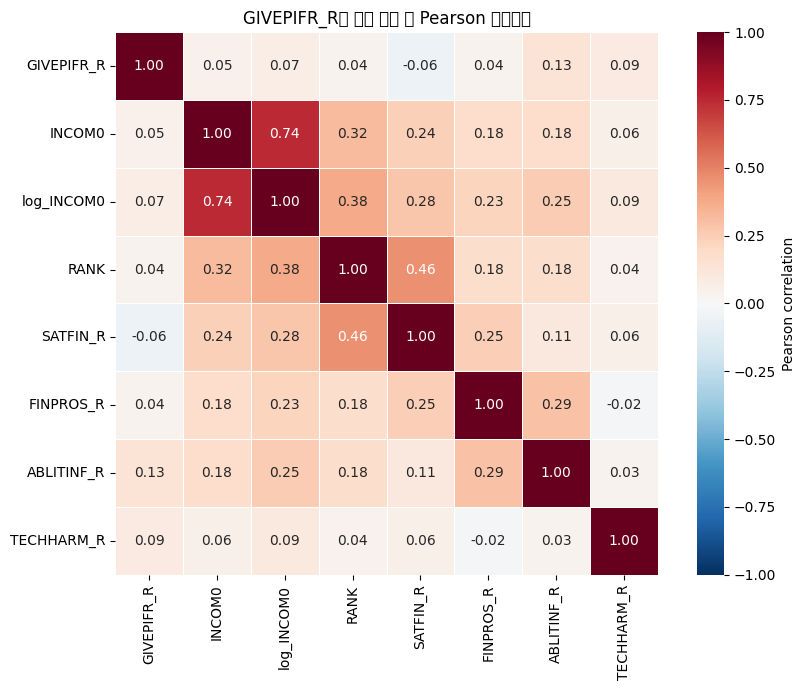

,INCOME_CAT,GIVEPIFR_R,GIVEPIFR_agree
0,0-2,2.051948,0.090909
1,3-5,2.395833,0.208333
2,6-8,2.652015,0.241758
3,9-11,2.450450,0.211712
4,12-14,2.520833,0.187500
5,15-17,2.419355,0.233871
6,18-21,2.576271,0.237288


In [5]:
summary_vars = [
    "GIVEPIFR", "GIVEPIFR_R", "GIVEPIFR_agree",
    "INCOME", "INCOM0", "log_INCOM0", "RANK",
    "SATFIN", "SATFIN_R", "FINPROS", "FINPROS_R",
    "AGE", "SEX", "EDUC", "ABLITINF", "ABLITINF_R", "TECHHARM", "TECHHARM_R",
]
display(df[summary_vars].describe().T)

corr_vars = ["GIVEPIFR_R", "INCOM0", "log_INCOM0", "RANK", "SATFIN_R", "FINPROS_R", "ABLITINF_R", "TECHHARM_R"]
corr_matrix = df[corr_vars].corr(method="pearson")
display(corr_matrix)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("GIVEPIFR_R와 핵심 변수 간 Pearson 상관관계")
plt.tight_layout()
plt.show()

income_cat_summary = (
    df.groupby("INCOME_CAT", observed=True)[["GIVEPIFR_R", "GIVEPIFR_agree"]]
      .mean()
      .reset_index()
)
display(income_cat_summary)

## 5. 모형 함수 정의

In [6]:
def fit_wls(formula, data, weight_col="FINALWT"):
    model_data = data.dropna(subset=[weight_col]).copy()
    return smf.wls(formula=formula, data=model_data, weights=model_data[weight_col]).fit()


def fit_logit(formula, data):
    return smf.logit(formula=formula, data=data).fit(disp=False, maxiter=200)


def tidy_result(res, model_name):
    out = pd.DataFrame({
        "term": res.params.index,
        "coef": res.params.values,
        "std_err": res.bse.values,
        "p_value": res.pvalues.values,
        "ci_low": res.conf_int().iloc[:, 0].values,
        "ci_high": res.conf_int().iloc[:, 1].values,
    })
    out.insert(0, "model", model_name)
    return out


def display_full_summary(res, model_name):
    print("=" * 100)
    print(model_name)
    print(res.summary())

key_terms = ["log_INCOM0", "RANK", "SATFIN_R", "FINPROS_R", "ABLITINF_R", "TECHHARM_R"]

## 6. 등분산성 검정

HC3 강건표준오차는 사용하지 않는다. 다만 회귀 가정 점검용으로 Breusch-Pagan 검정과 White 검정은 유지한다.

In [ ]:
assumption_formula_main = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK + SATFIN_R + FINPROS_R + AGE "
    "+ C(SEX) + EDUC + ABLITINF_R + TECHHARM_R"
)


def heteroskedasticity_tests(formula, data, model_name):
    preliminary_ols = smf.ols(formula=formula, data=data).fit()
    bp = het_breuschpagan(preliminary_ols.resid, preliminary_ols.model.exog)
    white = het_white(preliminary_ols.resid, preliminary_ols.model.exog)
    return pd.DataFrame([{
        "model": model_name,
        "nobs": int(preliminary_ols.nobs),
        "bp_lm_stat": bp[0],
        "bp_lm_pvalue": bp[1],
        "bp_f_stat": bp[2],
        "bp_f_pvalue": bp[3],
        "white_lm_stat": white[0],
        "white_lm_pvalue": white[1],
        "white_f_stat": white[2],
        "white_f_pvalue": white[3],
        "bp_heteroskedasticity_5pct": bp[1] < 0.05,
        "white_heteroskedasticity_5pct": white[1] < 0.05,
    }])

heteroskedasticity_results = heteroskedasticity_tests(
    assumption_formula_main,
    df,
    "ASSUMPTION_OLS_GIVEPIFR_R_logINCOM0_main",
)
display(heteroskedasticity_results)

## 7. 주 분석: GIVEPIFR_R WLS 회귀분석

주 분석은 객관적 계층 변수로 `log_INCOM0`를 사용한다. 종속변수 `GIVEPIFR_R`은 값이 높을수록 개인정보 제공 동의 수준이 높다는 의미이다.

In [7]:
main_formula = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK + SATFIN_R + FINPROS_R + AGE "
    "+ C(SEX) + EDUC + ABLITINF_R + TECHHARM_R"
)

wls_model = fit_wls(main_formula, df)
tidy_wls = tidy_result(wls_model, "MAIN_WLS_GIVEPIFR_R_logINCOM0")

display(tidy_wls[tidy_wls["term"].isin(key_terms)].sort_values("term"))
display_full_summary(wls_model, "MAIN_WLS_GIVEPIFR_R_logINCOM0")

,model,term,coef,std_err,p_value,ci_low,ci_high
8,MAIN_WLS_GIVEPIFR_R_logINCOM0,ABLITINF_R,0.050658,0.037257,0.174216,-0.022448,0.123763
5,MAIN_WLS_GIVEPIFR_R_logINCOM0,FINPROS_R,-0.044312,0.047656,0.352666,-0.137823,0.049198
3,MAIN_WLS_GIVEPIFR_R_logINCOM0,RANK,0.060582,0.027121,0.025705,0.007366,0.113799
4,MAIN_WLS_GIVEPIFR_R_logINCOM0,SATFIN_R,-0.110572,0.043439,0.011055,-0.195808,-0.025335
9,MAIN_WLS_GIVEPIFR_R_logINCOM0,TECHHARM_R,0.049691,0.034441,0.149376,-0.017889,0.117270
2,MAIN_WLS_GIVEPIFR_R_logINCOM0,log_INCOM0,-0.030171,0.054249,0.578215,-0.136619,0.076276


MAIN_WLS_GIVEPIFR_R_logINCOM0
                            WLS Regression Results                            
Dep. Variable:             GIVEPIFR_R   R-squared:                       0.059
Model:                            WLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     7.331
Date:                Mon, 18 May 2026   Prob (F-statistic):           2.05e-10
Time:                        10:34:01   Log-Likelihood:                -1633.8
No. Observations:                1067   AIC:                             3288.
Df Residuals:                    1057   BIC:                             3337.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       

## 8. 표준화 WLS 회귀분석

단위가 다른 변수들의 상대적 계수 크기를 비교하기 위한 보조 분석이다.

In [ ]:
formula_z = (
    "GIVEPIFR_R ~ z_log_INCOM0 + z_RANK + z_SATFIN_R + z_FINPROS_R + z_AGE "
    "+ C(SEX) + EDUC + z_ABLITINF_R + z_TECHHARM_R"
)

z_wls_model = fit_wls(formula_z, df)
tidy_z_wls = tidy_result(z_wls_model, "Z_WLS_GIVEPIFR_R")
z_key_terms = ["z_log_INCOM0", "z_RANK", "z_SATFIN_R", "z_FINPROS_R", "z_AGE", "z_ABLITINF_R", "z_TECHHARM_R"]

display(tidy_z_wls[tidy_z_wls["term"].isin(z_key_terms)].sort_values("term"))
display_full_summary(z_wls_model, "Z_WLS_GIVEPIFR_R")

## 9. 주 분석: GIVEPIFR_agree 로지스틱 회귀분석

`GIVEPIFR_agree`는 원척도 `GIVEPIFR`가 1 또는 2인 경우 1, 3/4/5인 경우 0이다. 따라서 1은 개인정보 제공에 동의한다는 뜻이다.

In [8]:
logit_formula = (
    "GIVEPIFR_agree ~ log_INCOM0 + RANK + SATFIN_R + FINPROS_R + AGE "
    "+ C(SEX) + EDUC + ABLITINF_R + TECHHARM_R"
)

logit_model = fit_logit(logit_formula, df)
tidy_logit = tidy_result(logit_model, "MAIN_LOGIT_GIVEPIFR_agree_logINCOM0")

display(tidy_logit[tidy_logit["term"].isin(key_terms)].sort_values("term"))
display_full_summary(logit_model, "MAIN_LOGIT_GIVEPIFR_agree_logINCOM0")

,model,term,coef,std_err,p_value,ci_low,ci_high
8,MAIN_LOGIT_GIVEPIFR_agree_logINCOM0,ABLITINF_R,0.180538,0.087795,0.039748,0.008463,0.352613
5,MAIN_LOGIT_GIVEPIFR_agree_logINCOM0,FINPROS_R,-0.066540,0.109958,0.545085,-0.282054,0.148974
3,MAIN_LOGIT_GIVEPIFR_agree_logINCOM0,RANK,0.116302,0.061865,0.060116,-0.004951,0.237555
4,MAIN_LOGIT_GIVEPIFR_agree_logINCOM0,SATFIN_R,-0.178840,0.100859,0.076201,-0.376521,0.018840
9,MAIN_LOGIT_GIVEPIFR_agree_logINCOM0,TECHHARM_R,0.028877,0.080730,0.720573,-0.129351,0.187104
2,MAIN_LOGIT_GIVEPIFR_agree_logINCOM0,log_INCOM0,-0.024219,0.115869,0.834433,-0.251317,0.202880


MAIN_LOGIT_GIVEPIFR_agree_logINCOM0
                           Logit Regression Results                           
Dep. Variable:         GIVEPIFR_agree   No. Observations:                 1067
Model:                          Logit   Df Residuals:                     1057
Method:                           MLE   Df Model:                            9
Date:                Mon, 18 May 2026   Pseudo R-squ.:                 0.03289
Time:                        10:34:33   Log-Likelihood:                -540.34
converged:                       True   LL-Null:                       -558.72
Covariance Type:            nonrobust   LLR p-value:                 2.911e-05
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.1853      0.922     -0.201      0.841      -1.993       1.623
C(SEX)[T.2.0]     0.2920      0.160      1.830      0.067      -0.021       0.605
log_

## 10. 축약 통제변수 모형

통제변수를 `AGE`, `SEX`, `EDUC`로 제한한 보조 모형이다.

In [ ]:
formula_basic_wls = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK + SATFIN_R + FINPROS_R + AGE "
    "+ C(SEX) + EDUC"
)
formula_basic_logit = (
    "GIVEPIFR_agree ~ log_INCOM0 + RANK + SATFIN_R + FINPROS_R + AGE "
    "+ C(SEX) + EDUC"
)

basic_wls_model = fit_wls(formula_basic_wls, df)
basic_logit_model = fit_logit(formula_basic_logit, df)

basic_key_terms = ["log_INCOM0", "RANK", "SATFIN_R", "FINPROS_R", "AGE", "C(SEX)[T.2.0]", "EDUC"]

tidy_basic_wls = tidy_result(basic_wls_model, "BASIC_WLS_GIVEPIFR_R_logINCOM0")
tidy_basic_logit = tidy_result(basic_logit_model, "BASIC_LOGIT_GIVEPIFR_agree_logINCOM0")

display(tidy_basic_wls[tidy_basic_wls["term"].isin(basic_key_terms)].sort_values("term"))
display(tidy_basic_logit[tidy_basic_logit["term"].isin(basic_key_terms)].sort_values("term"))

## 11. 다중공선성 점검: VIF

In [ ]:
vif_formula_main = (
    "GIVEPIFR_R ~ log_INCOM0 + RANK + SATFIN_R + FINPROS_R + AGE "
    "+ C(SEX) + EDUC + ABLITINF_R + TECHHARM_R"
)


def calculate_vif(formula, data, model_name):
    y, X = dmatrices(formula, data=data, return_type="dataframe")
    rows = []
    for i, col in enumerate(X.columns):
        if col == "Intercept":
            continue
        rows.append({
            "model": model_name,
            "term": col,
            "vif": variance_inflation_factor(X.values, i),
        })
    return pd.DataFrame(rows).sort_values("vif", ascending=False).reset_index(drop=True)

vif_results = calculate_vif(vif_formula_main, df, "VIF_main_GIVEPIFR_logINCOM0_model")
display(vif_results)

## 12. 강건성 분석: INCOME_CAT 범주형 소득 변수 사용

주 분석의 `log_INCOM0` 대신 범주형 소득 변수 `INCOME_CAT`을 사용하여 소득 측정 방식이 달라져도 결과가 유지되는지 확인한다.

In [ ]:
robust_formula_income_cat = (
    "GIVEPIFR_R ~ C(INCOME_CAT) + RANK + SATFIN_R + FINPROS_R + AGE "
    "+ C(SEX) + EDUC + ABLITINF_R + TECHHARM_R"
)
robust_logit_formula = (
    "GIVEPIFR_agree ~ C(INCOME_CAT) + RANK + SATFIN_R + FINPROS_R + AGE "
    "+ C(SEX) + EDUC + ABLITINF_R + TECHHARM_R"
)

robust_wls_model = fit_wls(robust_formula_income_cat, df)
robust_logit_model = fit_logit(robust_logit_formula, df)

robust_tidy_wls = tidy_result(robust_wls_model, "ROBUST_WLS_GIVEPIFR_R_INCOME_cat")
robust_tidy_logit = tidy_result(robust_logit_model, "ROBUST_LOGIT_GIVEPIFR_agree_INCOME_cat")

robust_terms = robust_tidy_wls["term"].apply(lambda x: x.startswith("C(INCOME_CAT)") or x in ["RANK", "SATFIN_R", "FINPROS_R", "ABLITINF_R", "TECHHARM_R"])
display(robust_tidy_wls[robust_terms].sort_values("term"))

robust_logit_terms = robust_tidy_logit["term"].apply(lambda x: x.startswith("C(INCOME_CAT)") or x in ["RANK", "SATFIN_R", "FINPROS_R", "ABLITINF_R", "TECHHARM_R"])
display(robust_tidy_logit[robust_logit_terms].sort_values("term"))

display_full_summary(robust_wls_model, "ROBUST_WLS_GIVEPIFR_R_INCOME_cat")
display_full_summary(robust_logit_model, "ROBUST_LOGIT_GIVEPIFR_agree_INCOME_cat")

## 13. 해석 기준 요약

- `GIVEPIFR_R`은 값이 높을수록 할인/무료상품을 위한 개인정보 제공 동의가 높다는 의미이다.
- WLS 회귀에서 계수가 양수이면 해당 변수가 증가할수록 개인정보 제공 동의 수준이 높아지는 방향이다.
- `GIVEPIFR_agree`는 개인정보 제공 동의 여부이다. 로짓 계수가 양수이면 해당 변수가 증가할수록 개인정보 제공에 동의할 가능성이 높아지는 방향이다.
- `SATFIN_R`, `FINPROS_R`, `ABLITINF_R`는 모두 값이 높을수록 각각 가계상태 만족, 가계경제 전망 긍정, 정보판별능력이 높다는 뜻이다.
- `TECHHARM_R`는 값이 높을수록 기술위험 인식이 높다는 뜻이다.